In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os

# print(os.path.exists("/content/drive/MyDrive/ML/Machine Learning code"))

True


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

ANN_PATH = '/content/drive/MyDrive/ML/Machine Learning code/SnapshotSerengeti_v2_1_annotations.csv' #CHANGE TO UR OWN PATHS
IMG_CSV_PATH = '/content/drive/MyDrive/ML/Machine Learning code/SnapshotSerengeti_v2_1_images.csv' #CHANGE TO UR OWN PATHS

def prepare_serengeti_data(ann_path, img_path):
    ann_df = pd.read_csv(ann_path, low_memory=False)
    img_df = pd.read_csv(img_path, low_memory=False)

    df = pd.merge(img_df, ann_df, on='capture_id')

    # KEEP BLANK IMG and only remove rows with missing species
    df = df.dropna(subset=['question__species'])

    # Convert count column
    df['question__count_median'] = pd.to_numeric(df['question__count_median'], errors='coerce')
    df['question__count_median'] = (df['question__count_median'].fillna(0))

    # standardize species names by removing spaces and standardising species name to all lower case
    df['question__species'] = (df['question__species'].astype(str).str.strip().str.lower())


    # creating binary label for binary classification
    df['is_animal'] = (df['question__species'] != 'blank').astype(int)


    print("Before confidence filtering:")
    print(df['question__species'].value_counts().head(20))
    print("Blank count:", (df['question__species'] == 'blank').sum())


    # keep only high confidence labels for expert verified pictures
    df = df[df['p_users_identified_this_species'] >= 0.80]

    # Remove rare animal species BUT NEVER REMOVE BLANK
    animal_df = df[df['question__species'] != 'blank']
    blank_df = df[df['question__species'] == 'blank']

    species_counts = (animal_df['question__species'].value_counts())

    valid_species = species_counts[species_counts >= 50].index # keeps only species with 50 or more samples
    animal_df = animal_df[animal_df['question__species'].isin(valid_species)]

    print("Animal species kept:", animal_df['question__species'].nunique())
    print("Blank images:", len(blank_df))

    # Balance blank vs animal images so that they are the same number.
    if len(blank_df) > len(animal_df):
        blank_df = blank_df.sample(len(animal_df), random_state=42 )
    elif len(animal_df) > len(blank_df):
        animal_df = animal_df.sample(len(blank_df), random_state=42)

    df = pd.concat([animal_df, blank_df], ignore_index=True)

    # species labeling
    df['species_idx'], species_names = pd.factorize(df['question__species'])

    #animal count
    def bucket_count(x):
        if x <= 0:
            return 0
        elif x == 1:
            return 1
        elif x == 2:
            return 2
        elif 3 <= x <= 5:
            return 3
        else:
            return 4

    df['count_idx'] = (df['question__count_median'].apply(bucket_count))


    print("\nBinary distribution:")
    print(df['is_animal'].value_counts())

    print("\nSpecies count:")
    print(df['question__species'].nunique())

    print("\nBlank count:")
    print((df['question__species'] == 'blank').sum())

    print("\nFinal Dataset Size:", len(df))

    return df, species_names

In [ ]:
cleaned_df, species_list = prepare_serengeti_data(ANN_PATH, IMG_CSV_PATH)

print("\nDataset loaded successfully")
print("Rows:", len(cleaned_df))
print("Species:", len(species_list))

Before confidence filtering:
question__species
blank              5445842
wildebeest          533478
zebra               352892
gazellethomsons     323326
buffalo              61283
hartebeest           58780
elephant             53607
human                47015
gazellegrants        46465
giraffe              44376
impala               43503
warthog              43136
guineafowl           33112
otherbird            30744
hyenaspotted         21998
lionfemale           16605
eland                15839
topi                 12177
baboon                9013
cheetah               6806
Name: count, dtype: int64
Blank count: 5445842
Animal species kept: 48
Blank images: 5300905

Binary distribution:
is_animal
1    1466769
0    1466769
Name: count, dtype: int64

Species count:
49

Blank count:
1466769

Final Dataset Size: 2933538

Dataset loaded successfully
Rows: 2933538
Species: 49


In [ ]:
import pandas as pd
import os
import urllib.request
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

# create subset (8,500 imgs)
df_subset, _ = train_test_split(
    cleaned_df,
    train_size=8500,
    stratify=cleaned_df['question__species'],
    random_state=42
)

df_subset.to_csv('/content/team10_subset.csv', index=False)  #CHANGE TO UR OWN PATHS

print(f"Subset size: {len(df_subset)}")
print(f"Species count: {df_subset['question__species'].nunique()}")

# match via id to get the web URLs
df_master_images = pd.read_csv('/content/drive/MyDrive/ML/Machine Learning code/SnapshotSerengeti_v2_1_images.csv', low_memory=False) #CHANGE TO UR OWN PATHS
target_ids = set(df_subset['capture_id'].astype(str).str.strip())
df_mini_paths = df_master_images[df_master_images['capture_id'].isin(target_ids)]

http_urls = [
    f"https://storage.googleapis.com/public-datasets-lila/snapshotserengeti-unzipped/{str(path).strip()}"
    for path in df_mini_paths['image_path_rel']
    if str(path).strip().lower().endswith('.jpg')
]

# download
DEST_DIR = '/content/wildlife_data/images'
os.makedirs(DEST_DIR, exist_ok=True)

def download_image(url):
    try:
        filename = url.split('/')[-1]
        dest_path = os.path.join(DEST_DIR, filename)
        if not os.path.exists(dest_path):
            urllib.request.urlretrieve(url, dest_path)
        return True
    except: return False

print(f"Downloading {len(http_urls)} images to {DEST_DIR}...")
with ThreadPoolExecutor(max_workers=50) as executor:
    results = list(tqdm(executor.map(download_image, http_urls), total=len(http_urls)))

print(f"Download complete. Successful: {sum(results)}")

Subset size: 8500
Species count: 42


  0%|          | 0/24445 [00:00<?, ?it/s]

Download complete. Successful: 24056


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# load data
df_merged = pd.read_csv('/content/team10_subset.csv') #CHANGE TO UR OWN PATHS
print(df_merged.columns.tolist())

df_merged['filename'] = df_merged['image_path_rel'].apply(
    lambda x: x.split('/')[-1]
)

df_merged["full_path"] = df_merged["filename"].apply(
    lambda x: os.path.join(DEST_DIR, x)
)

# keep only successfully downloaded images
df_merged = df_merged[df_merged["full_path"].apply(os.path.exists)].reset_index(drop=True)
print(f"Images available after filtering: {len(df_merged)}")


# remove rare species
species_counts = df_merged['question__species'].value_counts()

print("Before filtering:")
print("Minimum species count:", species_counts.min())
print(species_counts[species_counts < 5])

valid_species = species_counts[species_counts >= 10].index
df_merged = df_merged[df_merged['question__species'].isin(valid_species)].reset_index(drop=True)

print("Images remaining:", len(df_merged))

df_merged['question__species'] = (df_merged['question__species'].str.strip().str.lower())
df_merged['species_idx'], species_names = pd.factorize(df_merged['question__species'])

species_counts = df_merged['question__species'].value_counts()

print("\nAfter filtering:")
print("Minimum species count:", species_counts.min())
print("Number of species:", len(species_counts))

print("\nSpecies Distribution:")
print(df_merged['question__species'].value_counts())

print("\nLabel Check")
print("species_idx min =", df_merged['species_idx'].min())
print("species_idx max =", df_merged['species_idx'].max())

print(df_merged[['question__species', 'is_animal', 'species_idx', 'count_idx']].head())


class WildlifeDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir,row['filename'])

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new(
                'RGB',
                (224,224),
                color='black')

        if self.transform:
            image = self.transform(image)

        is_animal = int(row['is_animal'])
        species_label = int(row['species_idx'])
        count_class = int(row['count_idx'])

        return (
            image,
            torch.tensor(is_animal, dtype=torch.long),
            torch.tensor(species_label, dtype=torch.long),
            torch.tensor(count_class, dtype=torch.long)
        )


# Model ResNet
class MultiTaskResNet(nn.Module):
    def __init__(self, num_species):
        super().__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.binary_head = nn.Linear(in_feats, 2)
        self.species_head = nn.Linear(in_feats, num_species)
        self.count_head = nn.Linear(in_feats, 5)

    def forward(self, x):
        features = self.backbone(x)
        return {
            'binary': self.binary_head(features),
            'species': self.species_head(features),
            'count': self.count_head(features)
        }

# Transform
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomCrop((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


# Stratified Split
train_df, temp_df = train_test_split(
    df_merged,
    test_size=0.30,
    stratify=df_merged['question__species'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['question__species'],
    random_state=42
)

print(len(train_df))
print(len(val_df))
print(len(test_df))


train_ds = WildlifeDataset(
    train_df,
    DEST_DIR,
    transform=train_transform
)

val_ds = WildlifeDataset(
    val_df,
    DEST_DIR,
    transform=test_transform
)

test_ds = WildlifeDataset(
    test_df,
    DEST_DIR,
    transform=test_transform
)


# Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Dataset Split: {len(train_ds)} Train | {len(val_ds)} Val | {len(test_ds)} Test")

['Unnamed: 0_x', 'capture_id', 'image_rank_in_capture', 'image_path_rel', 'Unnamed: 0_y', 'season', 'site', 'roll', 'capture', 'capture_date_local', 'capture_time_local', 'subject_id', 'question__species', 'question__count_max', 'question__count_median', 'question__count_min', 'question__standing', 'question__resting', 'question__moving', 'question__eating', 'question__interacting', 'question__young_present', 'p_users_identified_this_species', 'pielous_evenness_index', 'question__horns_visible', 'is_animal', 'species_idx', 'count_idx']
Images available after filtering: 8366
Before filtering:
Minimum species count: 1
question__species
jackal          4
hare            3
serval          3
insectspider    3
vervetmonkey    3
birdother       3
reedbuck        3
fire            2
porcupine       2
mongoose        2
aardvark        2
reptiles        1
vulture         1
leopard         1
batearedfox     1
waterbuck       1
Name: count, dtype: int64
Images remaining: 8312

After filtering:
Min

In [ ]:
print("TRAIN")
print(train_df['is_animal'].value_counts())

print("\nVALIDATION")
print(val_df['is_animal'].value_counts())

print("\nTEST")
print(test_df['is_animal'].value_counts())

TRAIN
is_animal
0    2975
1    2843
Name: count, dtype: int64

VALIDATION
is_animal
0    638
1    609
Name: count, dtype: int64

TEST
is_animal
0    637
1    610
Name: count, dtype: int64


In [ ]:
import copy
from tqdm.notebook import tqdm
from torch.amp import GradScaler, autocast

print("Species count:", train_df['question__species'].nunique())
print("species_idx min:", train_df['species_idx'].min())
print("species_idx max:",train_df['species_idx'].max())

# focal loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        return (
            ((1 - pt) ** self.gamma)
            * ce_loss
        ).mean()


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

num_species = len(species_names)

print("num_species =", num_species)

model = MultiTaskResNet(num_species).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

criterion = FocalLoss()
scaler = GradScaler("cuda")
best_val_acc = 0.0

best_model_wts = copy.deepcopy(model.state_dict())
print(f"Training started on {device}")


# training loop for 8 epochs
for epoch in range(8)
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/8 [Train]",
        leave=False
    )

    for imgs, b_labels, s_labels, c_labels in train_pbar:
        imgs = imgs.to(device)
        b_labels = b_labels.to(device)
        s_labels = s_labels.to(device)
        c_labels = c_labels.to(device)
        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(imgs)
            loss_binary = criterion(outputs['binary'],bb_labels)
            loss_species = criterion(outputs['species'],bs_labels)
            loss_count = criterion(outputs['count'],bc_labels)
            loss = (loss_binary + loss_speciesb+ loss_count)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    # validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for imgs, _, s_labels, _ in val_loader:
            imgs = imgs.to(device)
            s_labels = s_labels.to(device)
            preds = torch.argmax(model(imgs)['species'], dim=1)
            val_correct += (preds == s_labels).sum().item()

    val_acc = val_correct / len(val_ds)
    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_wildlife_model.pth")
print(f"\nTraining Finished. Best Val Accuracy: {best_val_acc:.4f}")

Species count: 22
species_idx min: 0
species_idx max: 21
num_species = 22
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 103MB/s]


Training started on cuda


Epoch 1/8 [Train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.6269 | Val Acc: 0.8220


...

Epoch 6 | Loss: 0.1758 | Val Acc: 0.8861


Epoch 7/8 [Train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 7 | Loss: 0.1201 | Val Acc: 0.8853


Epoch 8/8 [Train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 8 | Loss: 0.0895 | Val Acc: 0.8877

Training Finished. Best Val Accuracy: 0.8893


In [ ]:
model.load_state_dict(
    torch.load(
        "best_wildlife_model.pth",
        map_location=device
    )
)

model.eval()


from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []
top5_correct = 0
total = 0

with torch.no_grad():
    for imgs, _, s_labels, _ in test_loader:
        imgs = imgs.to(device)
        s_labels = s_labels.to(device)
        outputs = model(imgs)["species"]

        # Top-1
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(s_labels.cpu().numpy())

        # Top-5
        _, top5 = outputs.topk(
            5,
            dim=1
        )

        top5_correct += (top5 == s_labels.view(-1,1)).sum().item()
        total += s_labels.size(0)

top1_acc = accuracy_score(
    all_labels,
    all_preds
)

top5_acc = top5_correct / total
macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print(f"Top-1 Accuracy : {top1_acc:.4f}")
print(f"Top-5 Accuracy : {top5_acc:.4f}")
print(f"Macro F1 Score : {macro_f1:.4f}")

Top-1 Accuracy : 0.8949
Top-5 Accuracy : 0.9848
Macro F1 Score : 0.5777


In [ ]:
from sklearn.metrics import accuracy_score

binary_preds = []
binary_labels = []
model.eval()

with torch.no_grad():
    for imgs, b_labels, _, _ in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)["binary"]
        preds = torch.argmax(outputs, dim=1)
        binary_preds.extend(preds.cpu().numpy())
        binary_labels.extend(b_labels.numpy())

binary_acc = accuracy_score(binary_labels, binary_preds)
print(f"Binary Accuracy: {binary_acc:.4f}")

Binary Accuracy: 0.9591


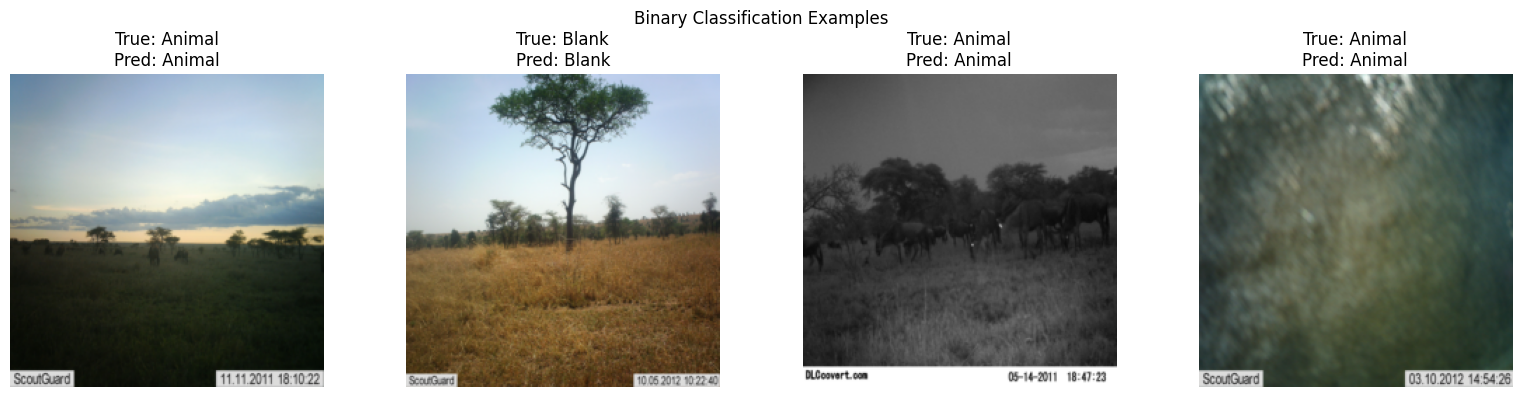

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()
examples = []

for imgs, b_labels, _, _ in test_loader:
    imgs = imgs.to(device)
    with torch.no_grad():
        outputs = model(imgs)["binary"]
        preds = outputs.argmax(dim=1)
    for i in range(len(imgs)):
        if preds[i].item() == b_labels[i].item():
            examples.append({
                "image": imgs[i].cpu(),
                "true": b_labels[i].item(),
                "pred": preds[i].item()
            })

        if len(examples) >= 4:
            break

    if len(examples) >= 4:
        break


fig, axes = plt.subplots(1, 4, figsize=(16,4))

mean = torch.tensor(
    [0.485,0.456,0.406]
).view(3,1,1)

std = torch.tensor(
    [0.229,0.224,0.225]
).view(3,1,1)

for ax, ex in zip(axes, examples):
    img = ex["image"]
    img = img * std + mean
    img = img.clamp(0,1)
    img = img.numpy().transpose(1,2,0)
    ax.imshow(img)

    true_name = (
        "Animal"
        if ex["true"] == 1
        else "Blank"
    )

    pred_name = (
        "Animal"
        if ex["pred"] == 1
        else "Blank"
    )

    ax.set_title(f"True: {true_name}\nPred: {pred_name}")
    ax.axis("off")

plt.suptitle("Binary Classification Examples")
plt.tight_layout()
plt.show()

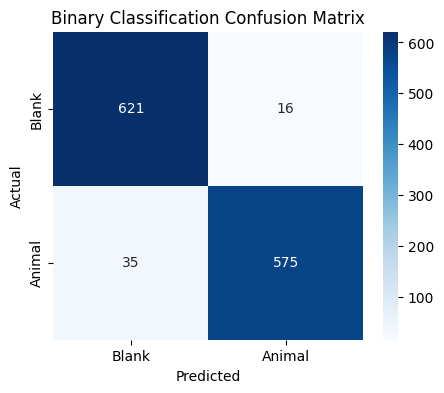

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_binary = confusion_matrix(
    binary_labels,
    binary_preds
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_binary,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Blank', 'Animal'],
    yticklabels=['Blank', 'Animal']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary Classification Confusion Matrix")

plt.show()

In [ ]:
count_preds = []
count_labels = []
model.eval()

with torch.no_grad():
    for imgs, _, _, c_labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)["count"]
        preds = torch.argmax(outputs, dim=1)
        count_preds.extend(preds.cpu().numpy())
        count_labels.extend(c_labels.numpy())

count_acc = accuracy_score(
    count_labels,
    count_preds
)

print(f"Count Accuracy: {count_acc:.4f}")

Count Accuracy: 0.7642


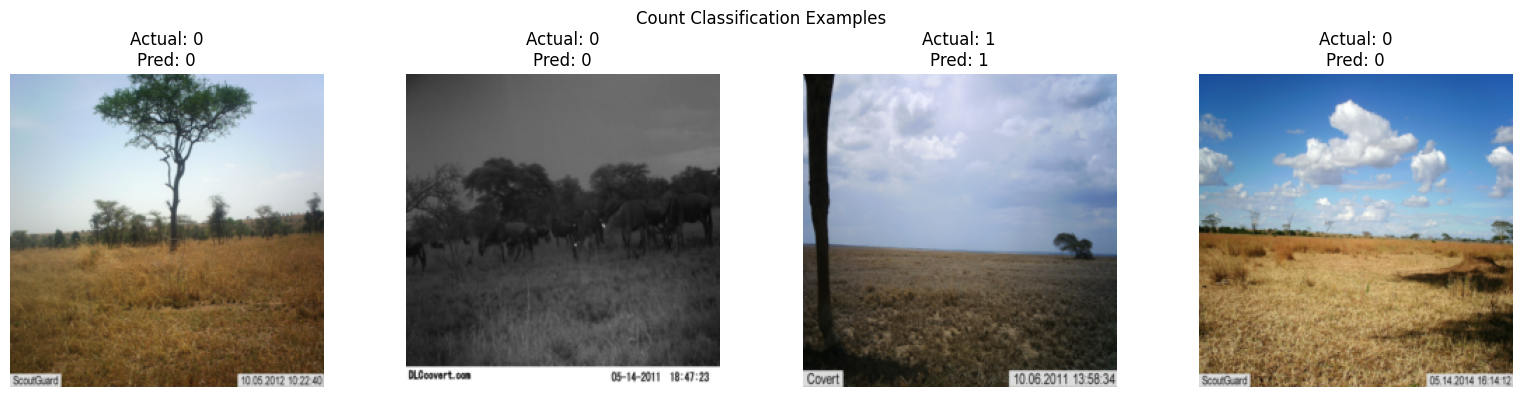

In [ ]:
model.eval()
examples = []

for imgs, _, _, c_labels in test_loader:
    imgs = imgs.to(device)
    with torch.no_grad():
        outputs = model(imgs)["count"]
        preds = outputs.argmax(dim=1)

    for i in range(len(imgs)):
        if preds[i].item() == c_labels[i].item():
            examples.append({
                "image": imgs[i].cpu(),
                "true": c_labels[i].item(),
                "pred": preds[i].item()
            })
        if len(examples) >= 4:
            break

    if len(examples) >= 4:
        break


bucket_names = [
    "0",
    "1",
    "2",
    "3-5",
    ">5"
]

fig, axes = plt.subplots(1, 4, figsize=(16,4))

for ax, ex in zip(axes, examples):
    img = ex["image"]
    img = img * std + mean
    img = img.clamp(0,1)
    img = img.numpy().transpose(1,2,0)
    ax.imshow(img)
    ax.set_title(
        f"Actual: {bucket_names[ex['true']]}\n"
        f"Pred: {bucket_names[ex['pred']]}"
    )

    ax.axis("off")

plt.suptitle("Count Classification Examples")
plt.tight_layout()
plt.show()

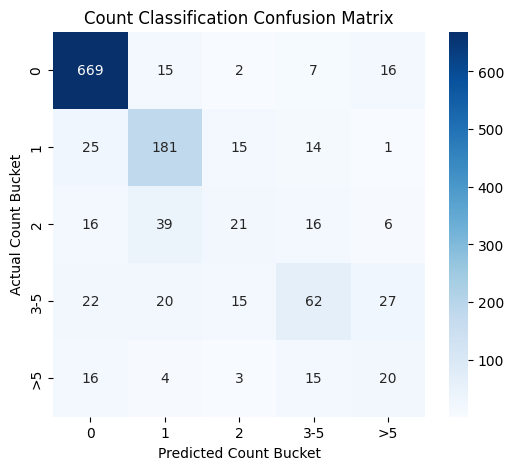

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_count = confusion_matrix(
    count_labels,
    count_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_count,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0','1','2','3-5','>5'],
    yticklabels=['0','1','2','3-5','>5']
)

plt.xlabel("Predicted Count Bucket")
plt.ylabel("Actual Count Bucket")
plt.title("Count Classification Confusion Matrix")

plt.show()

In [ ]:
species_mapping = (
    train_df[['question__species', 'species_idx']]
    .drop_duplicates()
    .sort_values('species_idx')
    .reset_index(drop=True)
)

species_mapping

,question__species,species_idx
0,blank,0
1,zebra,1
2,buffalo,2
3,gazellethomsons,3
4,wildebeest,4
5,warthog,5
6,giraffe,6
7,elephant,7
8,otherbird,8
9,hyenaspotted,9


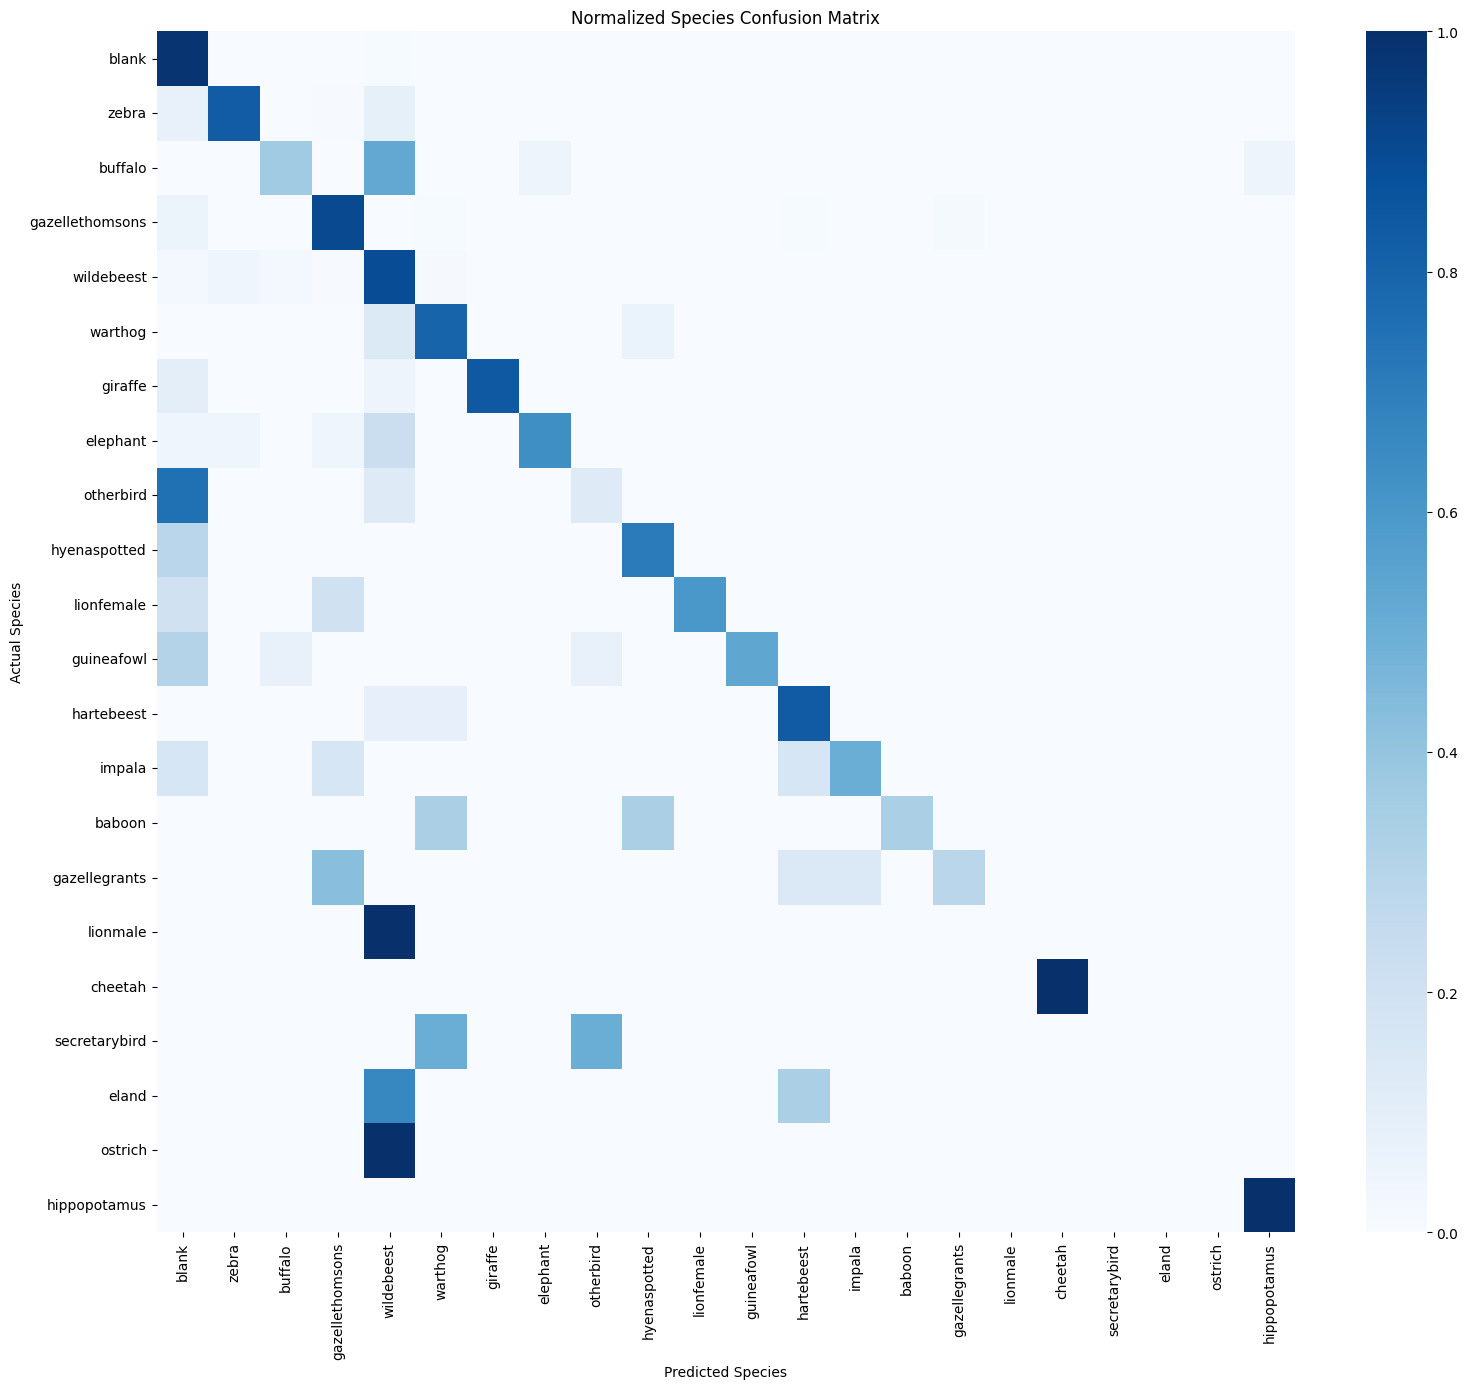

In [ ]:
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_preds
)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(16,14))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=species_names,
    yticklabels=species_names
)

plt.title("Normalized Species Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(all_labels, all_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       637
           1       0.91      0.83      0.87       146
           2       0.58      0.37      0.45        19
           3       0.93      0.90      0.92       115
           4       0.81      0.89      0.85       202
           5       0.63      0.80      0.71        15
           6       0.94      0.84      0.89        19
           7       0.93      0.64      0.76        22
           8       0.33      0.12      0.18         8
           9       0.71      0.71      0.71         7
          10       1.00      0.60      0.75         5
          11       0.78      0.54      0.64        13
          12       0.71      0.83      0.77        12
          13       0.75      0.50      0.60         6
          14       1.00      0.33      0.50         3
          15       0.50      0.29      0.36         7
          16       0.00      0.00      0.00         1
          17       1.00    

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

print("Generating Grad-CAM...")

# map species names
species_names = (
    train_df[['question__species', 'species_idx']]
    .drop_duplicates()
    .sort_values('species_idx')
)['question__species'].tolist()

# hook ResNet50 final convolution block
target_layer = model.backbone.layer4[-1]
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

forward_handle = target_layer.register_forward_hook(forward_hook)

backward_handle = target_layer.register_full_backward_hook(backward_hook)

# generate Multiple Grad-CAM
model.eval()

examples = []
blank_idx = None

if "blank" in species_names:
    blank_idx = species_names.index("blank")

# find 1 blank image and 3 different animal species to test
selected_species = set()

for images, _, species, _ in test_loader:
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)['species']
        preds = outputs.argmax(dim=1)

    correct_mask = preds.cpu() == species

    for idx in torch.where(correct_mask)[0]:
        idx = idx.item()
        true_label = species[idx].item()
        pred_label = preds[idx].item()

        # blank example
        if (
            blank_idx is not None
            and true_label == blank_idx
            and not any(
                e["type"] == "blank"
                for e in examples
            )
        ):

            examples.append({
                "type": "blank",
                "image": images[idx:idx+1],
                "true": true_label,
                "pred": pred_label
            })

        # Animal example
        elif (blank_idx is None or true_label != blank_idx):
            if true_label not in selected_species:
                selected_species.add(true_label)
                examples.append({
                    "type": "animal",
                    "image": images[idx:idx+1],
                    "true": true_label,
                    "pred": pred_label
                })

        # stop when have 1 blank + 3 animals
        animal_count = sum(
            e["type"] == "animal"
            for e in examples
        )

        blank_count = sum(
            e["type"] == "blank"
            for e in examples
        )

        if (animal_count >= 3 and blank_count >= 1):
            break

    animal_count = sum(
        e["type"] == "animal"
        for e in examples
    )

    blank_count = sum(
        e["type"] == "blank"
        for e in examples
    )

    if (animal_count >= 3 and blank_count >= 1):
        break

print(f"Found {len(examples)} examples")


# plot grad CAM map for each of the example
for ex_num, example in enumerate(examples):
    img_tensor = example["image"]

    true_species_idx = example["true"]
    pred_species_idx = example["pred"]

    activations.clear()
    gradients.clear()

    outputs = model(img_tensor)
    species_output = outputs["species"]

    # confidence
    probabilities = torch.softmax(species_output, dim=1)
    confidence = probabilities[0, pred_species_idx].item()
    model.zero_grad()
    score = species_output[0, pred_species_idx]
    score.backward()

    #grad CAM calculation
    activation = activations[0][0].detach().cpu().numpy()
    gradient = gradients[0][0].detach().cpu().numpy()
    weights = np.mean(gradient, axis=(1, 2))
    cam = np.zeros(activation.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * activation[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # get original img
    img = img_tensor[0].detach().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    img = img.clamp(0,1)
    img = img.numpy().transpose(1,2,0)

    #  show heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap.astype(np.float32) / 255.0
    overlay = 0.6 * img + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Display results taking 4 examples (including 1 blank one)
    true_name = species_names[true_species_idx]
    pred_name = species_names[pred_species_idx]
    fig, ax = plt.subplots(1,2,figsize=(12,6))

    ax[0].imshow(img)
    ax[0].set_title(f"Original\nTrue: {true_name}")
    ax[0].axis("off")

    ax[1].imshow(overlay)
    ax[1].set_title(f"Grad-CAM\n"
        f"Predicted: {pred_name}\n"
        f"Confidence: {confidence:.2%}"
    )
    ax[1].axis("off")
    plt.suptitle(f"Example {ex_num+1}")

    plt.tight_layout()
    plt.show()

forward_handle.remove()
backward_handle.remove()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# EfficientNet
import copy
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from tqdm.notebook import tqdm
from torch.amp import GradScaler, autocast
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_species = len(species_names)

class MultiTaskEfficientNet(nn.Module):
    def __init__(self, num_species):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_feats = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.binary_head = nn.Linear(in_feats, 2)
        self.species_head = nn.Linear(in_feats, num_species)
        self.count_head = nn.Linear(in_feats, 5)

    def forward(self, x):
        features = self.backbone(x)
        return {
            "binary": self.binary_head(features),
            "species": self.species_head(features),
            "count": self.count_head(features)
        }


efficientnet_model = MultiTaskEfficientNet(num_species).to(device)

optimizer = torch.optim.Adam(
    efficientnet_model.parameters(),
    lr=1e-4
)

criterion = FocalLoss()
scaler = GradScaler("cuda", enabled=(device.type == "cuda"))
best_val_acc = 0.0
best_model_wts = copy.deepcopy(efficientnet_model.state_dict())
print(f"EfficientNet training started on {device}")


# train EfficientNet
for epoch in range(8):
    efficientnet_model.train()
    running_loss = 0.0

    train_pbar = tqdm(
        train_loader,
        desc=f"EfficientNet Epoch {epoch+1}/8 [Train]",
        leave=False
    )

    for imgs, b_labels, s_labels, c_labels in train_pbar:
        imgs = imgs.to(device)
        b_labels = b_labels.to(device)
        s_labels = s_labels.to(device)
        c_labels = c_labels.to(device)
        optimizer.zero_grad()

        with autocast("cuda", enabled=(device.type == "cuda")):
            outputs = efficientnet_model(imgs)
            loss_binary = criterion(outputs["binary"], b_labels)
            loss_species = criterion(outputs["species"], s_labels)
            loss_count = criterion(outputs["count"], c_labels)
            loss = loss_binary + loss_species + loss_count

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    efficientnet_model.eval()
    val_correct = 0

    with torch.no_grad():
        for imgs, _, s_labels, _ in val_loader:
            imgs = imgs.to(device)
            s_labels = s_labels.to(device)
            preds = torch.argmax(
                efficientnet_model(imgs)["species"],
                dim=1
            )

            val_correct += (preds == s_labels).sum().item()
    val_acc = val_correct / len(val_ds)

    print(f"Epoch {epoch+1} | Loss: {running_loss / len(train_loader):.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(efficientnet_model.state_dict())
        torch.save(best_model_wts, "best_efficientnet_wildlife_model.pth")

print(f"\nEfficientNet Training Finished. Best Val Accuracy: {best_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 99.5MB/s]


EfficientNet training started on cuda


EfficientNet Epoch 1/8 [Train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 1 | Loss: 2.0464 | Val Acc: 0.7811


...

Epoch 6 | Loss: 0.4995 | Val Acc: 0.8749


EfficientNet Epoch 7/8 [Train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 7 | Loss: 0.4235 | Val Acc: 0.8749


EfficientNet Epoch 8/8 [Train]:   0%|          | 0/91 [00:00<?, ?it/s]

Epoch 8 | Loss: 0.3466 | Val Acc: 0.8725

EfficientNet Training Finished. Best Val Accuracy: 0.8749


EfficientNet Binary Accuracy: 0.9495


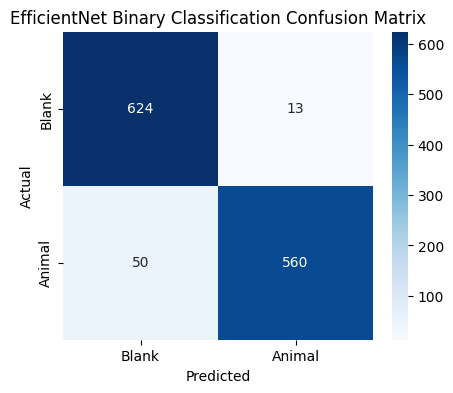

In [ ]:
# EfficientNet binary confusion matrix

eff_binary_preds = []
eff_binary_labels = []
efficientnet_model.eval()

with torch.no_grad():
    for imgs, b_labels, _, _ in test_loader:
        imgs = imgs.to(device)
        outputs = efficientnet_model(imgs)["binary"]
        preds = torch.argmax(outputs, dim=1)
        eff_binary_preds.extend(preds.cpu().numpy())
        eff_binary_labels.extend(b_labels.numpy())

eff_binary_acc = accuracy_score(eff_binary_labels, eff_binary_preds)
print(f"EfficientNet Binary Accuracy: {eff_binary_acc:.4f}")

cm_binary_eff = confusion_matrix(
    eff_binary_labels,
    eff_binary_preds
)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_binary_eff,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Blank", "Animal"],
    yticklabels=["Blank", "Animal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet Binary Classification Confusion Matrix")
plt.show()

In [ ]:
# efficientNet species eval

efficientnet_model.load_state_dict(torch.load("best_efficientnet_wildlife_model.pth",map_location=device))
efficientnet_model.eval()
eff_all_preds = []
eff_all_labels = []
eff_top5_correct = 0
eff_total = 0

with torch.no_grad():
    for imgs, _, s_labels, _ in test_loader:
        imgs = imgs.to(device)
        s_labels = s_labels.to(device)
        outputs = efficientnet_model(imgs)["species"]
        preds = torch.argmax(outputs, dim=1)
        eff_all_preds.extend(preds.cpu().numpy())
        eff_all_labels.extend(s_labels.cpu().numpy())

        _, top5 = outputs.topk(5, dim=1)

        eff_top5_correct += (top5 == s_labels.view(-1, 1)).sum().item()
        eff_total += s_labels.size(0)

eff_top1_acc = accuracy_score(eff_all_labels, eff_all_preds)
eff_top5_acc = eff_top5_correct / eff_total
eff_macro_f1 = f1_score(eff_all_labels, eff_all_preds, average="macro")

print(f"EfficientNet Top-1 Accuracy : {eff_top1_acc:.4f}")
print(f"EfficientNet Top-5 Accuracy : {eff_top5_acc:.4f}")
print(f"EfficientNet Macro F1 Score : {eff_macro_f1:.4f}")
print(classification_report(eff_all_labels, eff_all_preds, zero_division=0))

EfficientNet Top-1 Accuracy : 0.8733
EfficientNet Top-5 Accuracy : 0.9800
EfficientNet Macro F1 Score : 0.4577
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       637
           1       0.84      0.77      0.81       146
           2       0.73      0.58      0.65        19
           3       0.91      0.83      0.87       115
           4       0.81      0.89      0.85       202
           5       0.40      0.27      0.32        15
           6       0.94      0.84      0.89        19
           7       0.92      0.55      0.69        22
           8       0.00      0.00      0.00         8
           9       0.29      0.29      0.29         7
          10       0.67      0.40      0.50         5
          11       1.00      0.46      0.63        13
          12       0.77      0.83      0.80        12
          13       0.50      0.17      0.25         6
          14       0.00      0.00      0.00         3
          15       0.50 

EfficientNet Count Accuracy: 0.7546


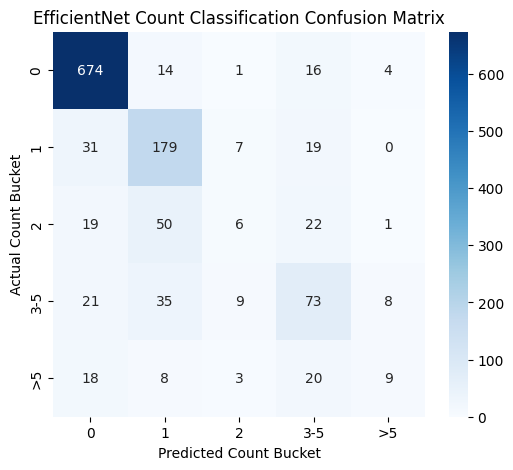

In [ ]:
# efficientNet aniaml count confusion matrix

eff_count_preds = []
eff_count_labels = []
efficientnet_model.eval()

with torch.no_grad():
    for imgs, _, _, c_labels in test_loader:
        imgs = imgs.to(device)
        outputs = efficientnet_model(imgs)["count"]
        preds = torch.argmax(outputs, dim=1)
        eff_count_preds.extend(preds.cpu().numpy())
        eff_count_labels.extend(c_labels.numpy())

eff_count_acc = accuracy_score(eff_count_labels, eff_count_preds)
print(f"EfficientNet Count Accuracy: {eff_count_acc:.4f}")

cm_count_eff = confusion_matrix(
    eff_count_labels,
    eff_count_preds
)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_count_eff,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1", "2", "3-5", ">5"],
    yticklabels=["0", "1", "2", "3-5", ">5"]
)

plt.xlabel("Predicted Count Bucket")
plt.ylabel("Actual Count Bucket")
plt.title("EfficientNet Count Classification Confusion Matrix")
plt.show()

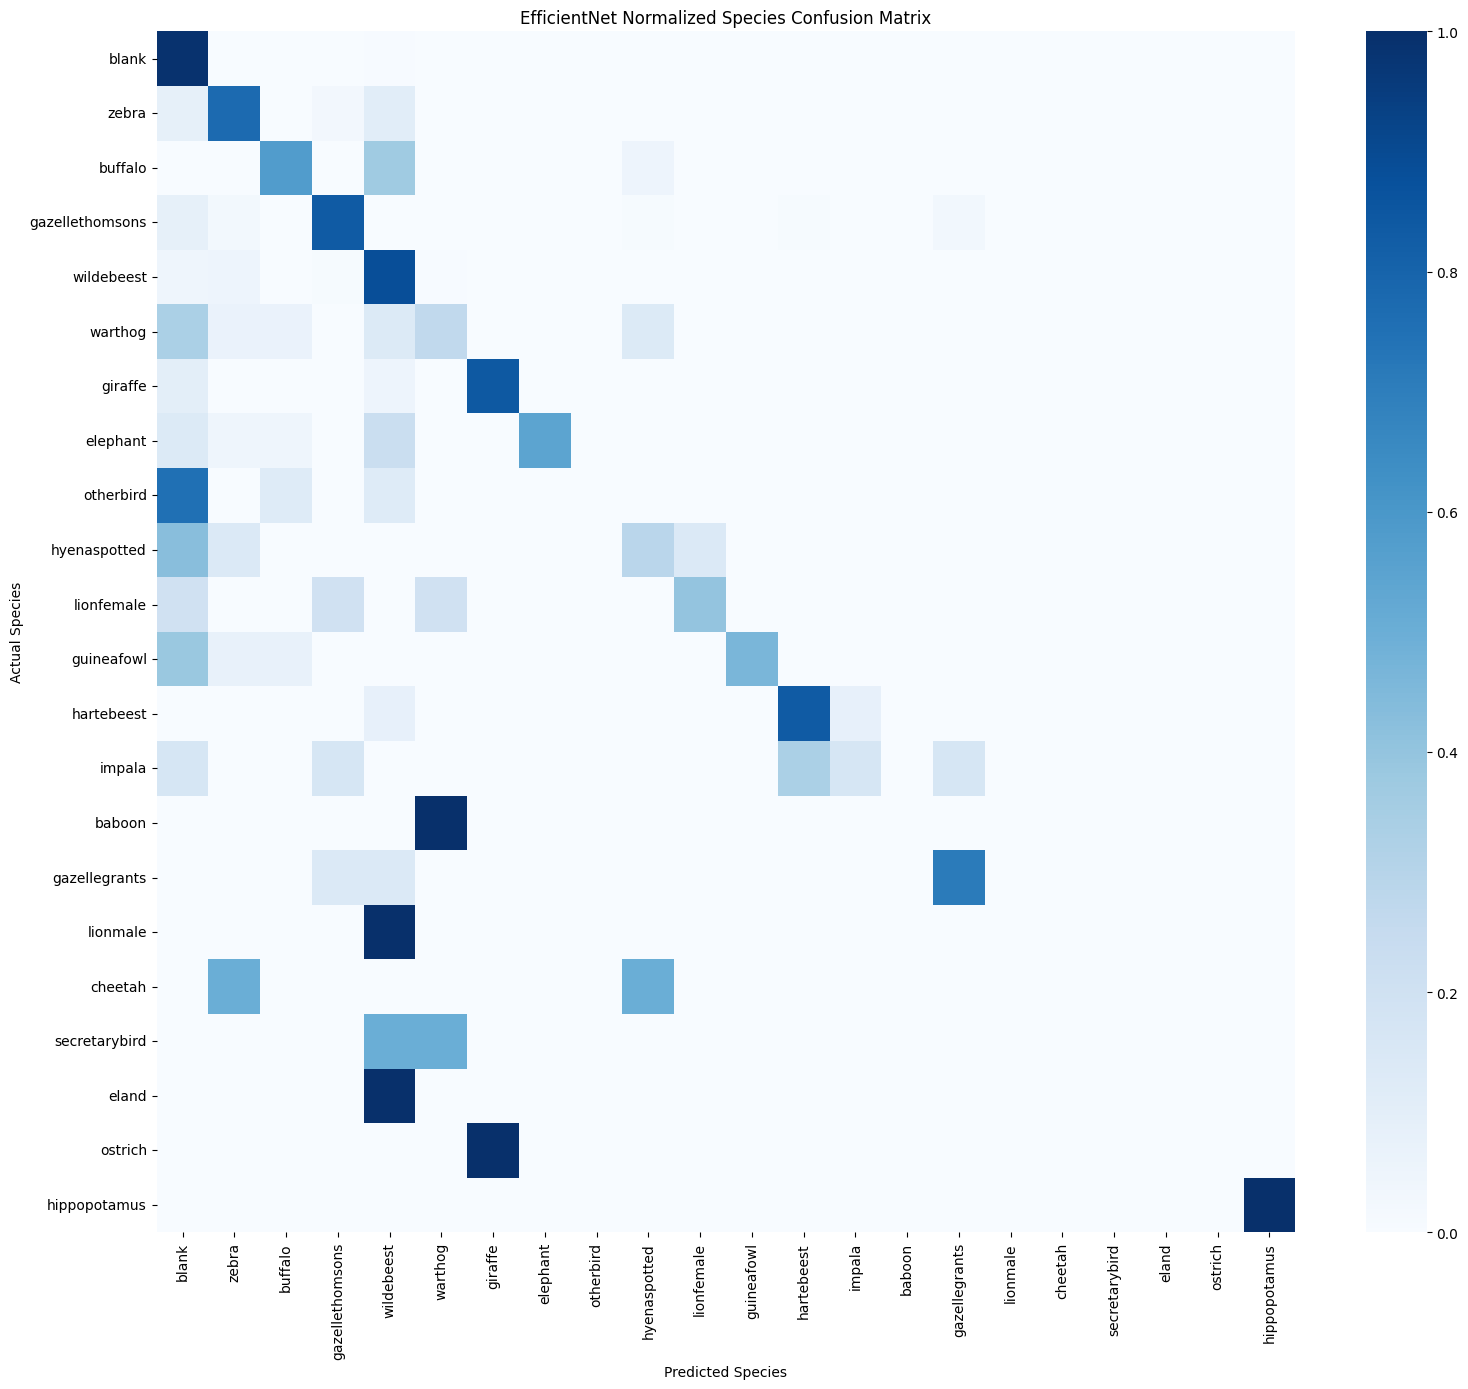

In [ ]:
# species heatmap

cm_eff = confusion_matrix(
    eff_all_labels,
    eff_all_preds
)
cm_eff_norm = cm_eff.astype("float") / cm_eff.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(16,14))

sns.heatmap(
    cm_eff_norm,
    cmap="Blues",
    xticklabels=species_names,
    yticklabels=species_names
)

plt.title("EfficientNet Normalized Species Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Grad-CAM
print("Generating EfficientNet Grad-CAM...")

species_names = (
    train_df[["question__species", "species_idx"]]
    .drop_duplicates()
    .sort_values("species_idx")
)["question__species"].tolist()

# final convolution block
target_layer = efficientnet_model.backbone.features[-1]
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)
efficientnet_model.eval()
examples = []
blank_idx = None

if "blank" in species_names:
    blank_idx = species_names.index("blank")

selected_species = set()

for images, _, species, _ in test_loader:
    images = images.to(device)
    with torch.no_grad():
        outputs = efficientnet_model(images)["species"]
        preds = outputs.argmax(dim=1)
    correct_mask = preds.cpu() == species

    for idx in torch.where(correct_mask)[0]:
        idx = idx.item()
        true_label = species[idx].item()
        pred_label = preds[idx].item()

        if (
            blank_idx is not None
            and true_label == blank_idx
            and not any(e["type"] == "blank" for e in examples)
        ):

            examples.append({
                "type": "blank",
                "image": images[idx:idx+1],
                "true": true_label,
                "pred": pred_label
            })

        elif blank_idx is None or true_label != blank_idx:
            if true_label not in selected_species:
                selected_species.add(true_label)
                examples.append({
                    "type": "animal",
                    "image": images[idx:idx+1],
                    "true": true_label,
                    "pred": pred_label
                })

        animal_count = sum(e["type"] == "animal" for e in examples)
        blank_count = sum(e["type"] == "blank" for e in examples)

        if animal_count >= 3 and blank_count >= 1:
            break

    animal_count = sum(e["type"] == "animal" for e in examples)
    blank_count = sum(e["type"] == "blank" for e in examples)

    if animal_count >= 3 and blank_count >= 1:
        break

print(f"Found {len(examples)} examples")

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

for ex_num, example in enumerate(examples):
    img_tensor = example["image"]
    true_species_idx = example["true"]
    pred_species_idx = example["pred"]

    activations.clear()
    gradients.clear()

    outputs = efficientnet_model(img_tensor)
    species_output = outputs["species"]

    probabilities = torch.softmax(species_output, dim=1)
    confidence = probabilities[0, pred_species_idx].item()
    efficientnet_model.zero_grad()
    score = species_output[0, pred_species_idx]
    score.backward()

    activation = activations[0][0].detach().cpu().numpy()
    gradient = gradients[0][0].detach().cpu().numpy()
    weights = np.mean(gradient, axis=(1, 2))
    cam = np.zeros(activation.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * activation[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    img = img_tensor[0].detach().cpu()
    img = img * std + mean
    img = img.clamp(0, 1)
    img = img.numpy().transpose(1, 2, 0)

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    heatmap = heatmap.astype(np.float32) / 255.0

    overlay = 0.6 * img + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    true_name = species_names[true_species_idx]
    pred_name = species_names[pred_species_idx]

    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    ax[0].imshow(img)
    ax[0].set_title(f"Original\nTrue: {true_name}")
    ax[0].axis("off")
    ax[1].imshow(overlay)
    ax[1].set_title(
        f"EfficientNet Grad-CAM\n"
        f"Predicted: {pred_name}\n"
        f"Confidence: {confidence:.2%}"
    )
    ax[1].axis("off")

    plt.suptitle(f"EfficientNet Example {ex_num+1}")
    plt.tight_layout()
    plt.show()

forward_handle.remove()
backward_handle.remove()

Output hidden; open in https://colab.research.google.com to view.